In [13]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

La Dérivatée en python

In [14]:
def f(x):
    return 3*x**2 - 4*x + 5

In [15]:
f(3.0)

20.0

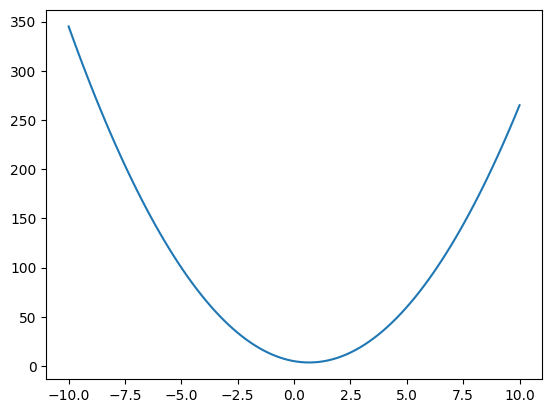

In [16]:
x = np.linspace(-10, 10, 100)
y = f(x)
plt.plot(x, y)

In [17]:
x = -3.0
h = 0.0000001
(f(x+h) - f(x)) / h

-21.999999688659955

In [18]:
x = 2.0
w = -3.0
b = 1.0
y = w*x + b
print(y)

-5.0


In [19]:
h = 0.0000001

x = 2.0
w = -3.0
b = 10.0

y1 = w*x + b
y2 = (w+h)*x + b

print(f"y1: {y1}")
print(f"y2: {y2}")
print(f"slope: {(y2-y1)/h}")

y1: 4.0
y2: 4.0000002
slope: 1.9999999967268423


In [20]:
h = 0.0000001

x = 2.0
w = -3.0
b = 10.0

y1 = w*x + b
y2 = w*x + (b + h)

print(f"y1: {y1}")
print(f"y2: {y2}")
print(f"slope: {(y2-y1)/h}")

y1: 4.0
y2: 4.000000099999999
slope: 0.999999993922529


In [21]:
class Value:
    def __init__(self, data):
        self.data = data
        
    def __repr__(self):
        return f'Value(data = {self.data})'

In [22]:
a = Value(1)
b = Value(2)
print(a, b)

Value(data = 1) Value(data = 2)


In [23]:
a + b

TypeError: unsupported operand type(s) for +: 'Value' and 'Value'

In [24]:
class Value:
    def __init__(self, data):
        self.data = data

    def __add__(self, other):
        return Value(self.data + other.data)
        
    def __repr__(self):
        return f'Value(data = {self.data})'

In [25]:
a = Value(1)
b = Value(2)
a + b

Value(data = 3)

In [26]:
class Value:
    def __init__(self, data):
        self.data = data
    
    def __repr__(self):
        return f'Value(data = {self.data})'

    def __add__(self, other):
        return Value(self.data + other.data)
    
    def __mul__(self, other):
        return Value(self.data * other.data)
    
a = Value(1)
b = Value(2)
c = Value(3)
a * b + c

Value(data = 5)

In [27]:
class Value:
    def __init__(self, data, _children = ()):
        self.data = data
        self._prev = _children
    
    def __repr__(self):
        return f'Value(data = {self.data})'

    def __add__(self, other):
        return Value(self.data + other.data, (self, other))
    
    def __mul__(self, other):
        return Value(self.data * other.data, (self, other))

a = Value(2)
b = Value(3)
c = Value(5)
d = a * b + c
d._prev

(Value(data = 6), Value(data = 5))

In [28]:
class Value:
    def __init__(self, data, _children = (), _op = ''):
        self.data = data
        self._prev = _children
        self._op = _op
    
    def __repr__(self):
        return f'Value(data = {self.data})'

    def __add__(self, other):
        return Value(self.data + other.data, (self, other), '+')
    
    def __mul__(self, other):
        return Value(self.data * other.data, (self, other), '*')

a = Value(2)
b = Value(3)
c = Value(5)
d = a * b + c
print(d.data, d._prev, d._op)

11 (Value(data = 6), Value(data = 5)) +


In [29]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{data %.4f}" % (n.data), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

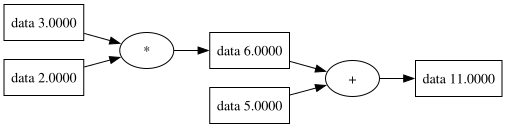

In [30]:
draw_dot(d)

In [31]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{data %.4f}" % (n.data), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

In [32]:
class Value:
    def __init__(self, data, _children = (), _op = '', label = ''):
        self.data = data
        self._prev = _children
        self._op = _op
        self.label = label
    
    def __repr__(self):
        return f'Value(data = {self.data})'

    def __add__(self, other):
        return Value(self.data + other.data, (self, other), '+')
    
    def __mul__(self, other):
        return Value(self.data * other.data, (self, other), '*')

a = Value(2, label = 'a')
b = Value(3, label='b')
c = Value(5, label='c')
e = a * b; e.label = 'a*b'
d = e + c; d.label = 'a*b+c'
f = Value(-2, label='f')
L = d * f; L.label = 'L'


In [33]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

In [34]:
draw_dot(L)

AttributeError: 'Value' object has no attribute 'grad'

In [35]:
class Value:
    def __init__(self, data, _children = (), _op = '', label = ''):
        self.data = data
        self.grad = 0
        self._prev = _children
        self._op = _op
        self.label = label
    
    def __repr__(self):
        return f'Value(data = {self.data})'

    def __add__(self, other):
        return Value(self.data + other.data, (self, other), '+')
    
    def __mul__(self, other):
        return Value(self.data * other.data, (self, other), '*')

a = Value(2, label = 'a')
b = Value(3, label='b')
c = Value(5, label='c')
e = a * b; e.label = 'a*b'
d = e + c; d.label = 'a*b+c'
f = Value(-2, label='f')
L = d * f; L.label = 'L'

In [36]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "%s | data %.4f | grad %.4f" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

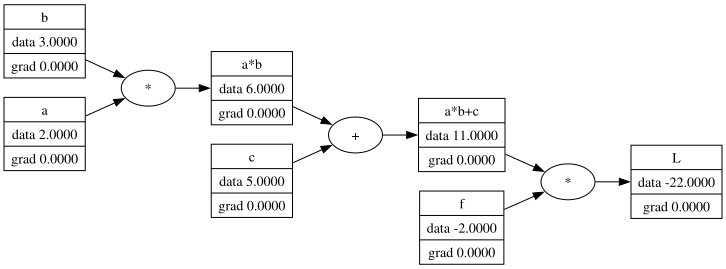

In [37]:
draw_dot(L)

In [38]:
def lol():
    a = Value(2, label = 'a')
    b = Value(3, label='b')
    c = Value(5, label='c')
    e = a * b; e.label = 'a*b'
    d = e + c; d.label = 'a*b+c'
    f = Value(-2, label='f')
    L1 = d * f; L.label = 'L'

    h = 0.0001

    a = Value(2, label = 'a')
    b = Value(3, label='b')
    c = Value(5, label='c')
    e = a * b; e.label = 'a*b'
    d = e + c; d.label = 'a*b+c'
    f = Value(-2+h, label='f')
    L2 = d * f; L.label = 'L'

    print((L2.data - L1.data) / h)


lol()

11.00000000000989


In [39]:
L.grad = 1.0

Calcul de tous les gradients de toutes les nodes

In [40]:
a.grad = -6
b.grad = -4
c.grad = -2
f.grad = 11

In [41]:
a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
f.data += 0.01 * f.grad

e = a * b
d = e + c
L = d * f

print(L.data)


-20.265336


Pour un Neurone maintenant

In [42]:
#input
x1 = Value(1, label='x1')
x2 = Value(-2, label='x2')

#weights
w1 = Value(3, label='w1')
w2 = Value(-1, label='w2')
b = Value(1, label='b')

w1x1 = w1 * x1; w1x1.label = 'w1*x1'
w2x2 = w2 * x2; w2x2.label = 'w2*x2'
w1x1_w2x2 = w1x1 + w2x2; w1x1_w2x2.label = 'w1*x1 + w2*x2'
n = w1x1_w2x2 + b; n.label = 'n'

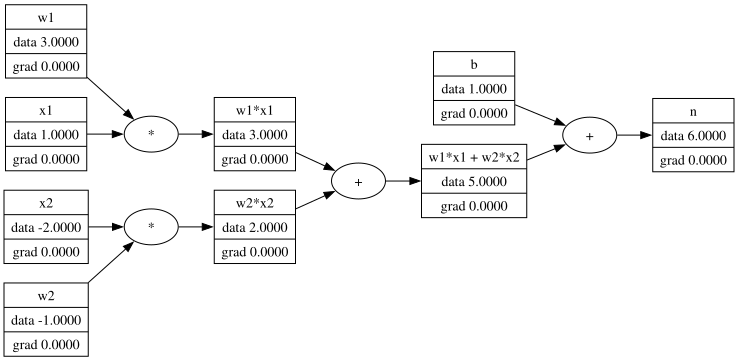

In [43]:
draw_dot(n)

In [44]:
class Value:
    def __init__(self, data, _children = (), _op = '', label = ''):
        self.data = data
        self.grad = 0
        self._prev = _children
        self._op = _op
        self.label = label
    
    def __repr__(self):
        return f'Value(data = {self.data})'

    def __add__(self, other):
        return Value(self.data + other.data, (self, other), '+')
    
    def __mul__(self, other):
        return Value(self.data * other.data, (self, other), '*')
    
    def tanh(self):
        return Value(math.tanh(self.data), (self,), 'tanh')

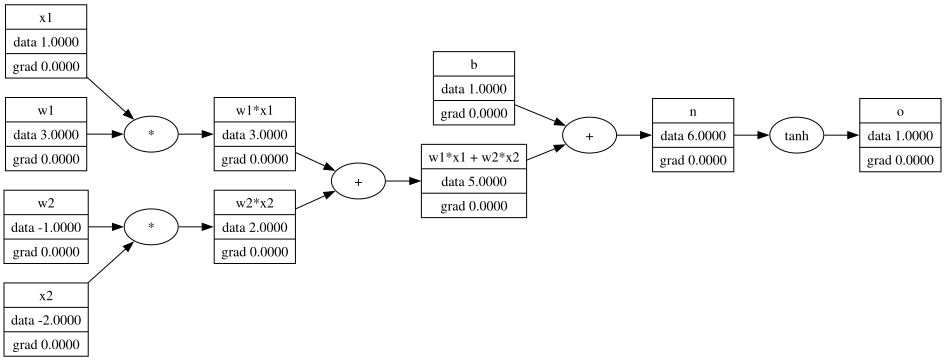

In [45]:
#input
x1 = Value(1, label='x1')
x2 = Value(-2, label='x2')

#weights
w1 = Value(3, label='w1')
w2 = Value(-1, label='w2')
b = Value(1, label='b')

w1x1 = w1 * x1; w1x1.label = 'w1*x1'
w2x2 = w2 * x2; w2x2.label = 'w2*x2'
w1x1_w2x2 = w1x1 + w2x2; w1x1_w2x2.label = 'w1*x1 + w2*x2'
n = w1x1_w2x2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'
draw_dot(o)

Calcul des gradient + changement de valeur

In [46]:
class Value:
    def __init__(self, data, _children = (), _op = '', label = ''):
        self.data = data
        self.grad = 0
        self._backward = lambda: None
        self._prev = _children
        self._op = _op
        self.label = label
    
    def __repr__(self):
        return f'Value(data = {self.data})'

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')
        
        def _backward():
            self.grad += 1 * out.grad
            other.grad += 1 * out.grad
        
        out._backward = _backward
        return out 
    
    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad

        out._backward = _backward
        return out
    
    def tanh(self):
        out = Value(math.tanh(self.data), (self,), 'tanh')

        def _backward():
            self.grad += (1.0 - math.tanh(self.data)**2) * out.grad

        out._backward = _backward
        return out

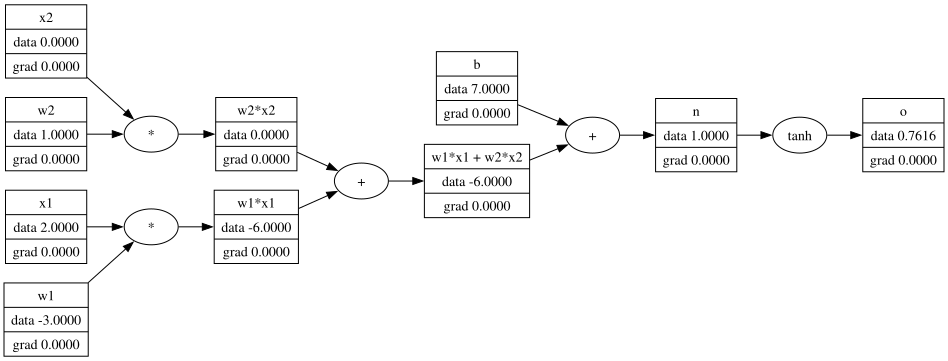

In [47]:
#input
x1 = Value(2, label='x1')
x2 = Value(0, label='x2')

#weights
w1 = Value(-3, label='w1')
w2 = Value(1, label='w2')
b = Value(7, label='b')

w1x1 = w1 * x1; w1x1.label = 'w1*x1'
w2x2 = w2 * x2; w2x2.label = 'w2*x2'
w1x1_w2x2 = w1x1 + w2x2; w1x1_w2x2.label = 'w1*x1 + w2*x2'
n = w1x1_w2x2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'
draw_dot(o)

In [48]:
o.grad = 1.0

In [49]:
o._backward()

In [50]:
n.grad

0.41997434161402614

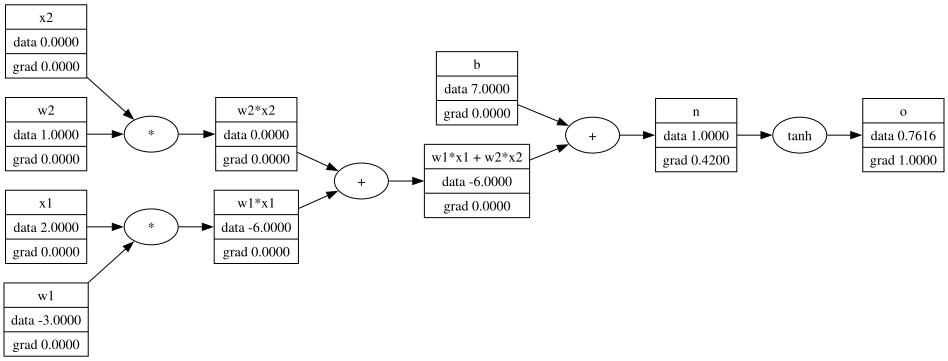

In [51]:
draw_dot(o)

In [52]:
n._backward()

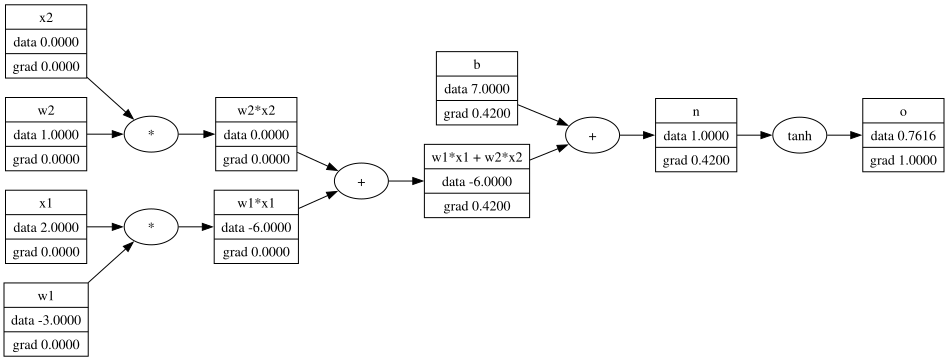

In [53]:
draw_dot(o)

In [54]:
b._backward()

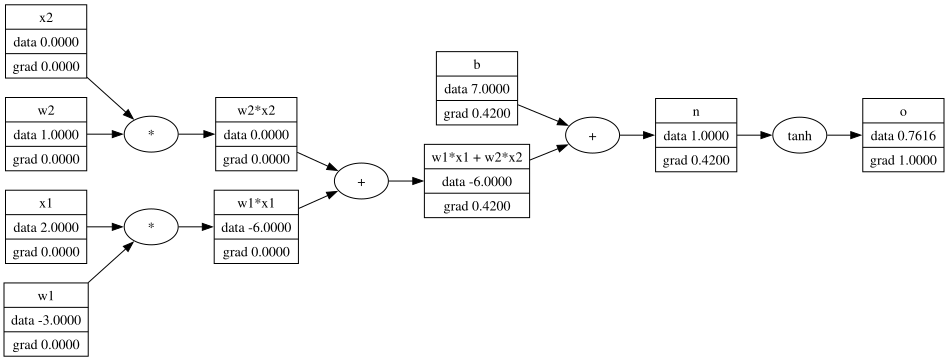

In [55]:
draw_dot(o)

In [56]:
w1x1_w2x2._backward()

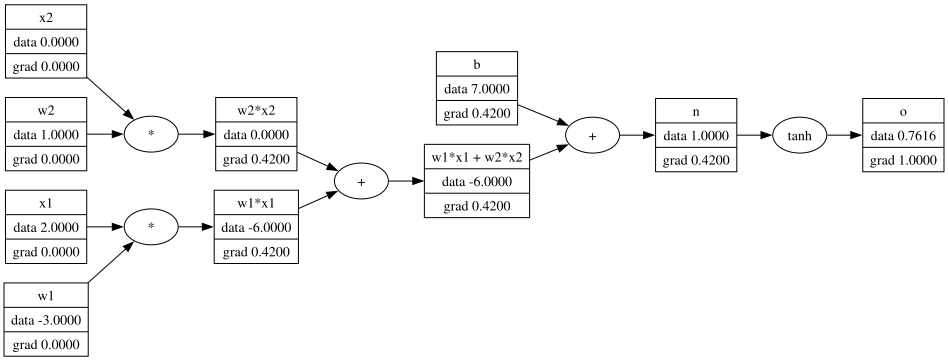

In [57]:
draw_dot(o)

In [58]:
w1x1._backward()
w2x2._backward()

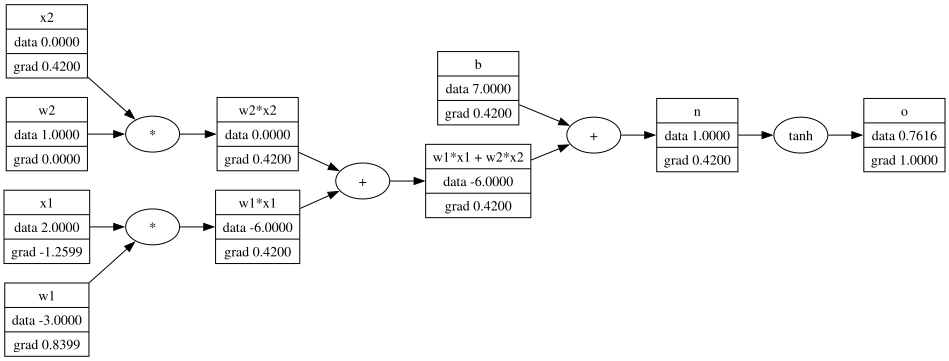

In [59]:
draw_dot(o)

In [60]:
topo = []
visited = set()
def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)
build_topo(o)
topo

[Value(data = -3),
 Value(data = 2),
 Value(data = -6),
 Value(data = 1),
 Value(data = 0),
 Value(data = 0),
 Value(data = -6),
 Value(data = 7),
 Value(data = 1),
 Value(data = 0.7615941559557649)]

In [61]:
o.grad = 1.0
for node in reversed(topo):
    node._backward()

In [62]:
class Value:
  
  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    self.grad = 0.0
    self._backward = lambda: None
    self._prev = set(_children)
    self._op = _op
    self.label = label

  def __repr__(self):
    return f"Value(data={self.data})"
  
  def __add__(self, other):
    out = Value(self.data + other.data, (self, other), '+')
    
    def _backward():
      self.grad = 1.0 * out.grad
      other.grad = 1.0 * out.grad
    out._backward = _backward
      
    return out

  def __mul__(self, other):
    out = Value(self.data * other.data, (self, other), '*')
    
    def _backward():
      self.grad = other.data * out.grad
      other.grad = self.data * out.grad
    out._backward = _backward
      
    return out
  
  def tanh(self):
    x = self.data
    t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
    out = Value(t, (self, ), 'tanh')
    
    def _backward():
      self.grad = (1 - t**2) * out.grad
    out._backward = _backward
    
    return out
  
  def backward(self):
    
    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)
    
    self.grad = 1.0
    for node in reversed(topo):
      node._backward()
        

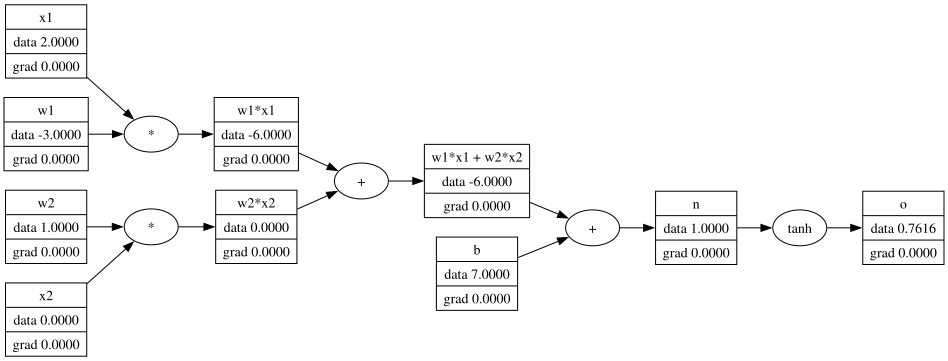

In [63]:
#input
x1 = Value(2, label='x1')
x2 = Value(0, label='x2')

#weights
w1 = Value(-3, label='w1')
w2 = Value(1, label='w2')
b = Value(7, label='b')

w1x1 = w1 * x1; w1x1.label = 'w1*x1'
w2x2 = w2 * x2; w2x2.label = 'w2*x2'
w1x1_w2x2 = w1x1 + w2x2; w1x1_w2x2.label = 'w1*x1 + w2*x2'
n = w1x1_w2x2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'
draw_dot(o)

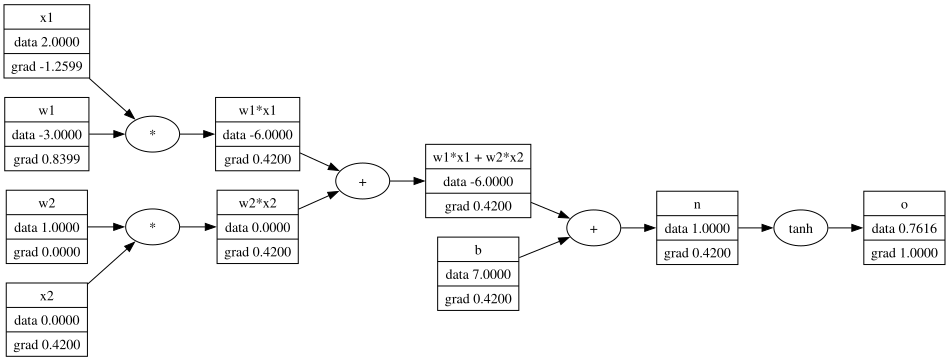

In [64]:
o.backward()
draw_dot(o)

Problème lol

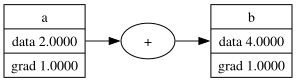

In [65]:
a = Value(2, label='a')
b = a + a; b.label = 'b'
b.backward()
draw_dot(b)

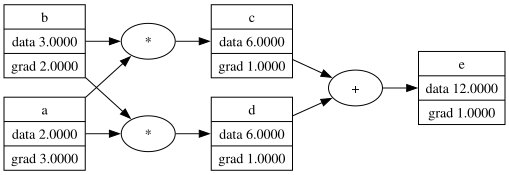

In [66]:
a = Value(2, label='a')
b = Value(3, label='b')
c = a * b; c.label = 'c'
d = a * b; d.label = 'd'
e = c + d; e.label = 'e'
e.backward()
draw_dot(e)

In [67]:
class Value:
  
  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    self.grad = 0.0
    self._backward = lambda: None
    self._prev = set(_children)
    self._op = _op
    self.label = label

  def __repr__(self):
    return f"Value(data={self.data})"
  
  def __add__(self, other):
    out = Value(self.data + other.data, (self, other), '+')
    
    def _backward():
      self.grad += 1.0 * out.grad
      other.grad += 1.0 * out.grad
    out._backward = _backward
      
    return out

  def __mul__(self, other):
    out = Value(self.data * other.data, (self, other), '*')
    
    def _backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad
    out._backward = _backward
      
    return out
  
  def tanh(self):
    x = self.data
    t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
    out = Value(t, (self, ), 'tanh')
    
    def _backward():
      self.grad += (1 - t**2) * out.grad
    out._backward = _backward
    
    return out
  
  def backward(self):
    
    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)
    
    self.grad = 1.0
    for node in reversed(topo):
      node._backward()

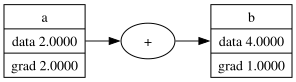

In [68]:
a = Value(2, label='a')
b = a + a; b.label = 'b'
b.backward()
draw_dot(b)

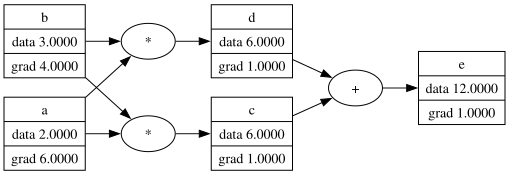

In [69]:
a = Value(2, label='a')
b = Value(3, label='b')
c = a * b; c.label = 'c'
d = a * b; d.label = 'd'
e = c + d; e.label = 'e'
e.backward()
draw_dot(e)

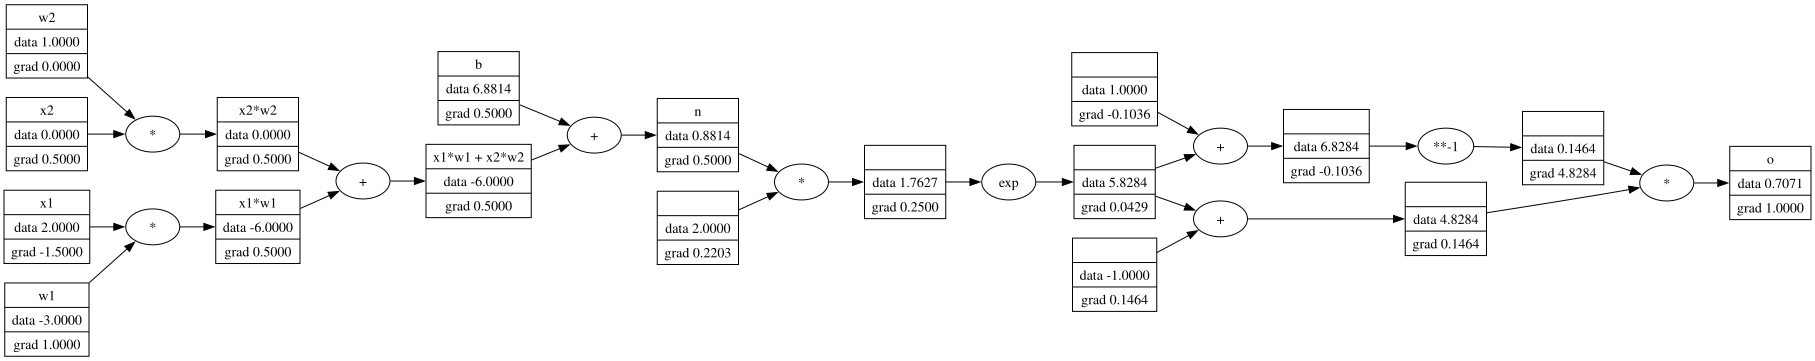

In [70]:
class Value:
  
  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    self.grad = 0.0
    self._backward = lambda: None
    self._prev = set(_children)
    self._op = _op
    self.label = label

  def __repr__(self):
    return f"Value(data={self.data})"
  
  def __add__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data + other.data, (self, other), '+')
    
    def _backward():
      self.grad += 1.0 * out.grad
      other.grad += 1.0 * out.grad
    out._backward = _backward
    
    return out

  def __mul__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data * other.data, (self, other), '*')
    
    def _backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad
    out._backward = _backward
      
    return out
  
  def __pow__(self, other):
    assert isinstance(other, (int, float)), "only supporting int/float powers for now"
    out = Value(self.data**other, (self,), f'**{other}')

    def _backward():
        self.grad += other * (self.data ** (other - 1)) * out.grad
    out._backward = _backward

    return out
  
  def __rmul__(self, other): # other * self
    return self * other

  def __truediv__(self, other): # self / other
    return self * other**-1

  def __neg__(self): # -self
    return self * -1

  def __sub__(self, other): # self - other
    return self + (-other)

  def __radd__(self, other): # other + self
    return self + other

  def tanh(self):
    x = self.data
    t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
    out = Value(t, (self, ), 'tanh')
    
    def _backward():
      self.grad += (1 - t**2) * out.grad
    out._backward = _backward
    
    return out
  
  def exp(self):
    x = self.data
    out = Value(math.exp(x), (self, ), 'exp')
    
    def _backward():
      self.grad += out.data * out.grad # NOTE: in the video I incorrectly used = instead of +=. Fixed here.
    out._backward = _backward
    
    return out
  
  
  def backward(self):
    
    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)
    
    self.grad = 1.0
    for node in reversed(topo):
      node._backward()

# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
# ----
e = (2*n).exp()
o = (e - 1) / (e + 1)
# ----
o.label = 'o'
o.backward()
draw_dot(o)

In [71]:
import torch

x1 = torch.Tensor([2.0]).double()                ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()                ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()               ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()                ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double()  ; b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

#input
x1 = Value(2, label='x1')
x2 = Value(0, label='x2')

#weights
w1 = Value(-3, label='w1')
w2 = Value(1, label='w2')
b = Value(6.8813735870195432, label='b')

w1x1 = w1 * x1; w1x1.label = 'w1*x1'
w2x2 = w2 * x2; w2x2.label = 'w2*x2'
w1x1_w2x2 = w1x1 + w2x2; w1x1_w2x2.label = 'w1*x1 + w2*x2'
n = w1x1_w2x2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

o.backward()

print('---')
print('x2', x2.grad)
print('w2', w2.grad)
print('x1', x1.grad)
print('w1', w1.grad)

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737
---
x2 0.4999999999999999
w2 0.0
x1 -1.4999999999999996
w1 0.9999999999999998


Création des classes matchant celle de pytorch

In [72]:
import random

class Neuron:
  
  def __init__(self, nin):
    self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
    self.b = Value(random.uniform(-1,1))
  
  def __call__(self, x):
    # w * x + b
    act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
    out = act.tanh()
    return out
  
  def parameters(self):
    return self.w + [self.b]

class Layer:
  
  def __init__(self, nin, nout):
    self.neurons = [Neuron(nin) for _ in range(nout)]
  
  def __call__(self, x):
    outs = [n(x) for n in self.neurons]
    return outs[0] if len(outs) == 1 else outs
  
  def parameters(self):
    return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:
  
  def __init__(self, nin, nouts):
    sz = [nin] + nouts
    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]
  
  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    return x
  
  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]

In [73]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)

Value(data=-0.537550215184971)

In [74]:
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets

In [75]:
for k in range(20):
  
  # forward pass
  ypred = [n(x) for x in xs]
  loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
  
  # backward pass
  for p in n.parameters():
    p.grad = 0.0
  loss.backward()
  
  # update
  for p in n.parameters():
    p.data += -0.1 * p.grad
  
  print(k, loss.data)

0 7.060021441219383
1 3.8637349828693353
2 2.830330123436167
3 1.7869116483122653
4 1.9043912629473903
5 0.1773041603585541
6 0.03187499108410764
7 0.026138305650643352
8 0.022638933058349537
9 0.02021904870426125
10 0.018412376077807022
11 0.016991904159132282
12 0.015832931385386717
13 0.014860857828480123
14 0.014028093382183644
15 0.01330270364048091
16 0.012662361963222126
17 0.012090918186549456
18 0.011576349430384441
19 0.01110948289128623


In [76]:
ypred

[Value(data=0.9551366971863905),
 Value(data=-0.939750131290487),
 Value(data=-0.9518223239307074),
 Value(data=0.9439140677086547)]

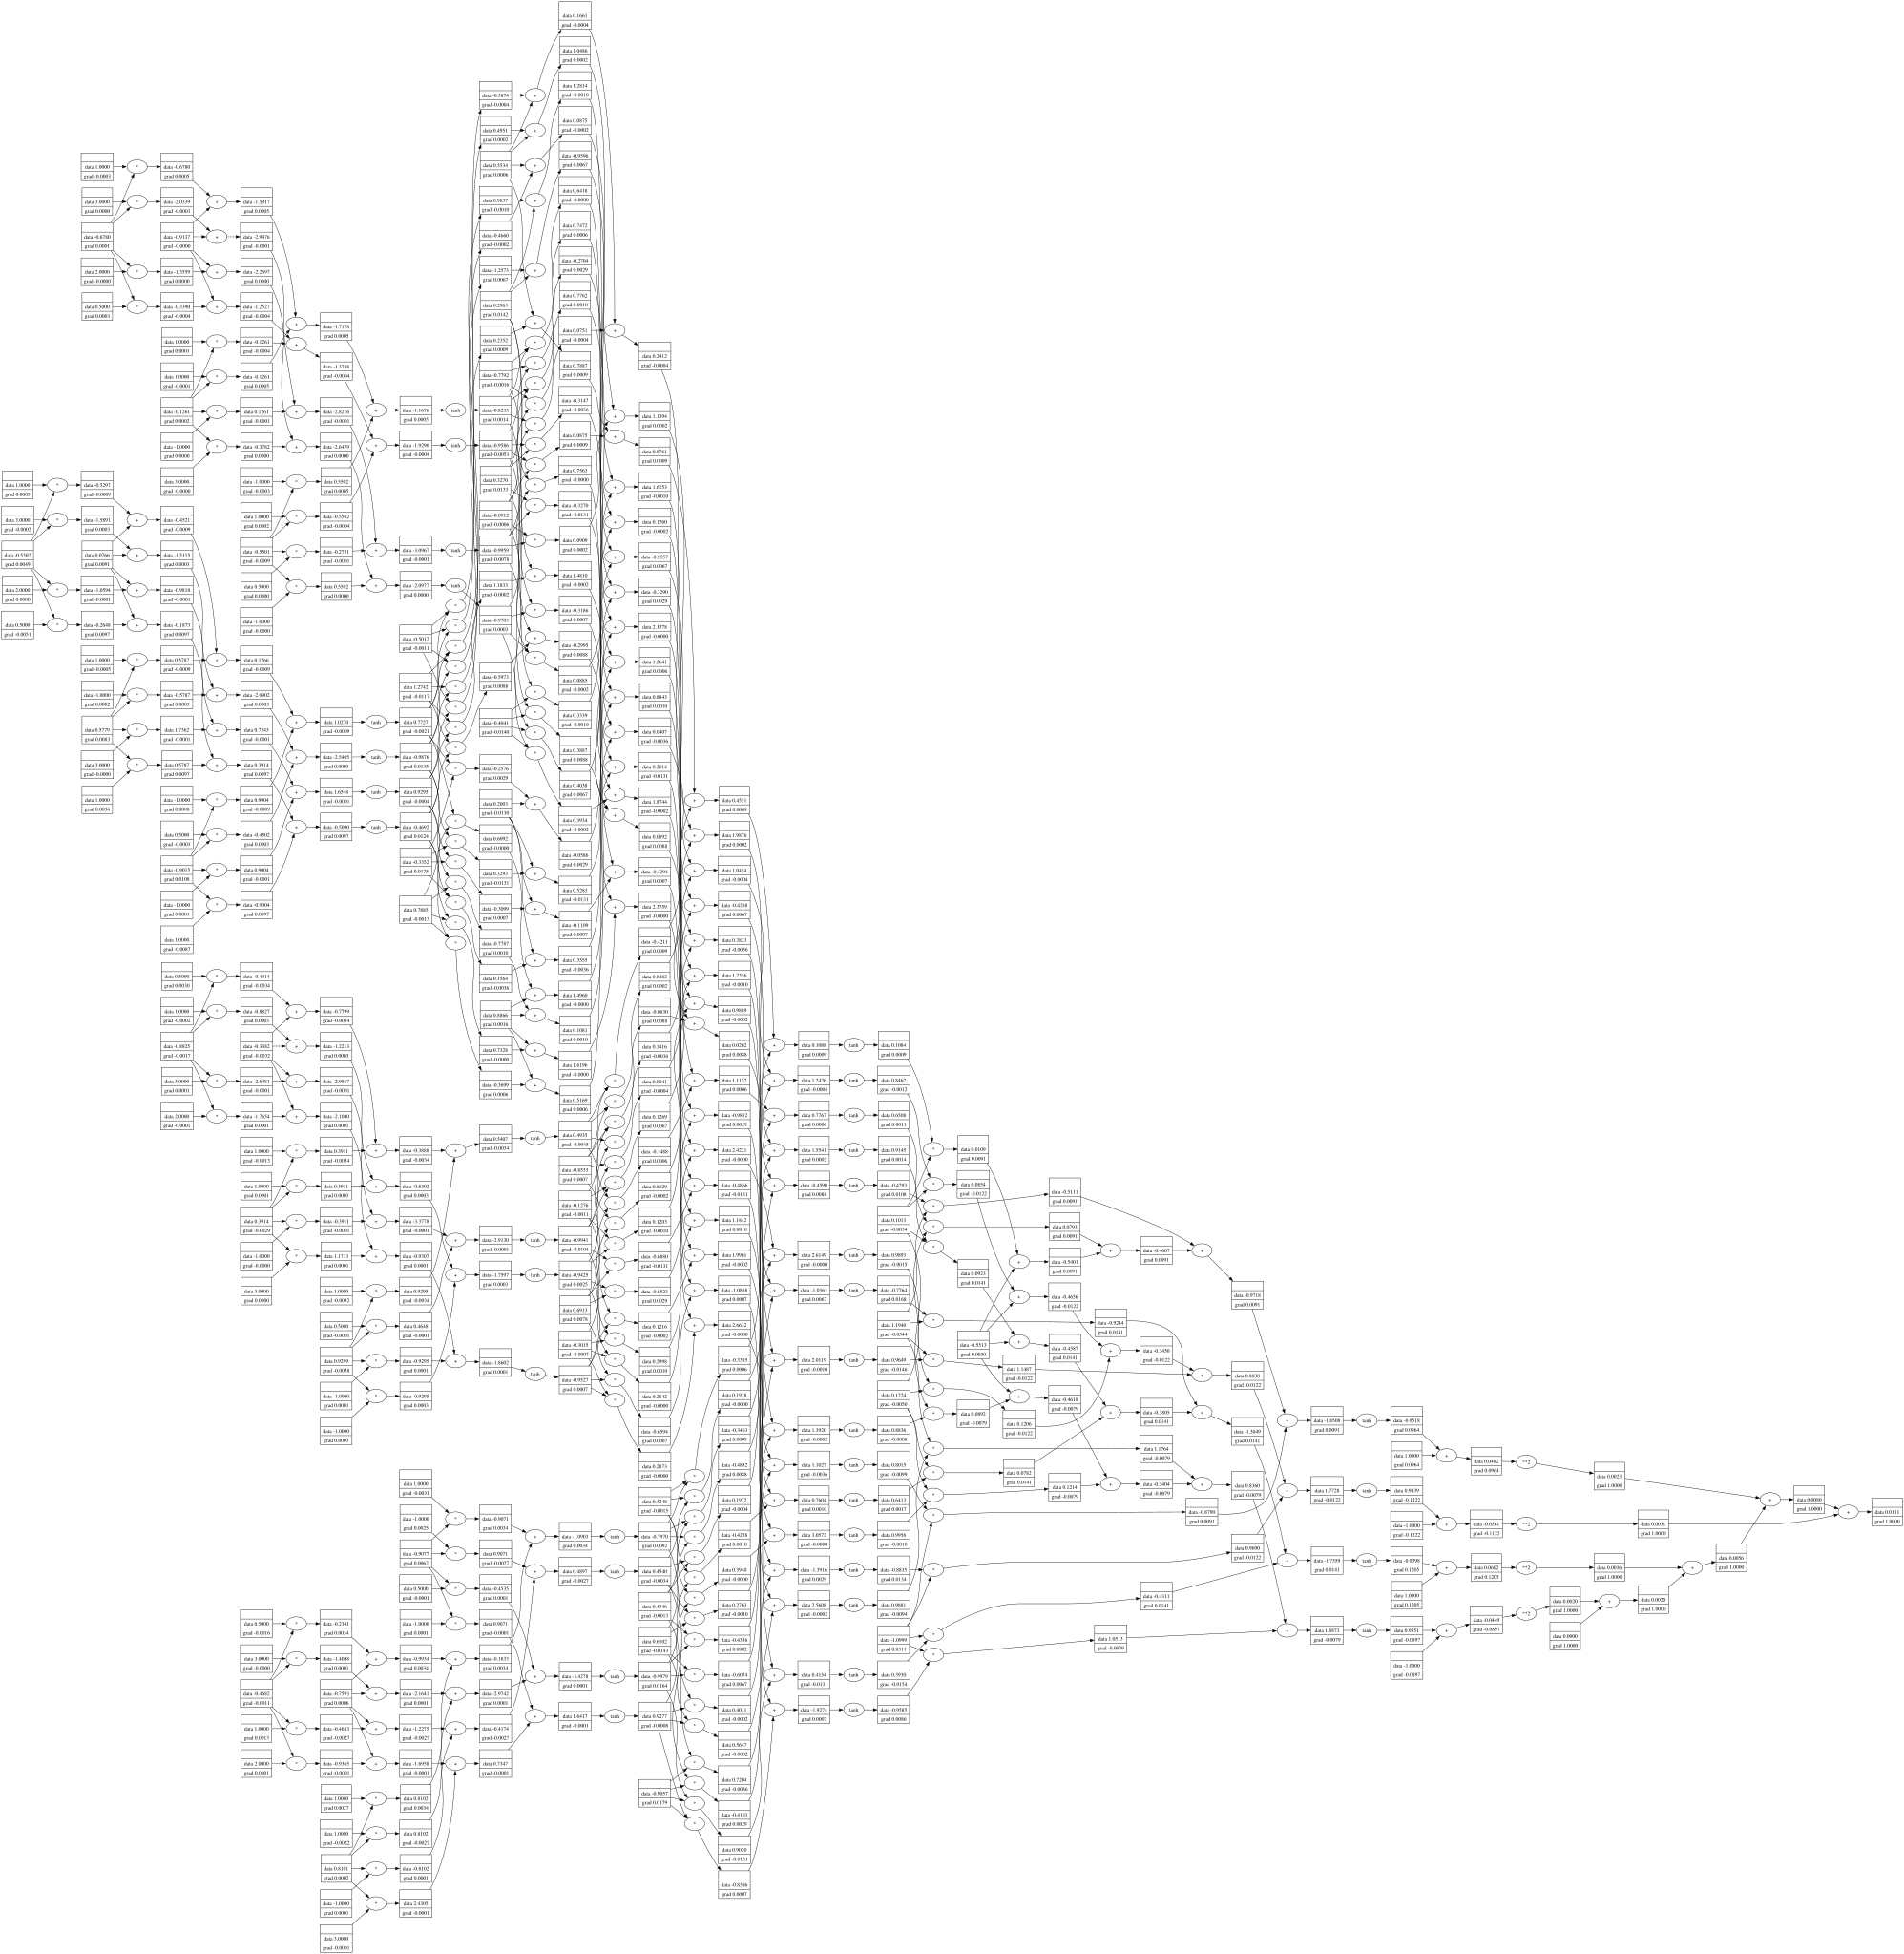

In [77]:
draw_dot(loss)

In [80]:
len(n.parameters()) #(3*4 + 4) + (4*4 + 4) + (4*1 + 1)

41